In [1]:
import zarr

dataset_path = '../dataset_generation/full_dataset/dataset.zarr'

# Open the dataset in read mode
root = zarr.open_group(dataset_path, mode='r')

dataset_size = 10000

# Access the arrays
X_flux = root["X_flux_coeffs"][:dataset_size]
X_wts  = root["X_weights"][:dataset_size]
Y_flux = root["Y_flux_coeffs"][:dataset_size]
Y_pow  = root["Y_power_coeffs"][:dataset_size]
Y_keff = root["Y_keff"][:dataset_size]
Y_wts  = root["Y_weights"][:dataset_size]

# Convert all of the surface indices to be in standard (ccw) convention
# indexing_convention_to_ccw_mapping = [0, 2, 1, 3]

# def indexing_convention_to_ccw(arr):
#     """Takes in a 4-tuple surface permutation in ccw order and converts it to one in the indexing convention."""

#     # First change the indices that the permutation refers to, from ccw order to the indexing convention.
#     arr = [ indexing_convention_to_ccw_mapping[i] for i in (3, 0, 1, 2) ]

#     # Now, we need to reorder the array to match the indexing convention.
#     arr = [ arr[indexing_convention_to_ccw_mapping[i]] for i in range(4) ]
#     return arr 

# Convert all data into pytorch tensors of the appropriate shape

import numpy as np
import torch

X_flux = np.moveaxis(X_flux, -1, 2)
Y_flux = np.moveaxis(Y_flux, -1, 2)

X_flux = torch.tensor(X_flux, dtype=torch.float32)
X_wts  = torch.tensor(X_wts, dtype=torch.float32)

Y_flux = torch.tensor(Y_flux, dtype=torch.float32)
Y_pow  = torch.tensor(Y_pow, dtype=torch.float32)
Y_keff = torch.tensor(Y_keff, dtype=torch.float32)
Y_wts  = torch.tensor(Y_wts, dtype=torch.float32)

In [2]:
# Flatten and concatenate inputs
X_flux_flat = X_flux.view(X_flux.size(0), -1)
X_input = torch.cat([X_flux_flat, X_wts], dim=1)

# Output sizes
out_flux_size = Y_flux.view(Y_flux.size(0), -1).size(1)
out_pow_size = Y_pow.view(Y_pow.size(0), -1).size(1)
out_wts_size = Y_wts.size(1)
out_keff_size = 1

In [3]:
import torch.nn as nn
import torch.nn.functional as F


def rotate_180_spatial(tensor, pos_encodings=False):
    """Rotate a 5D/6D tensor with shape (surfaces, channels, height, width, depth) or 
    (num_datapoints, surfaces, channels, height, width, depth) by 180 degrees in the 
    height and width dimensions.
    
    Parameters
    ----------
    pos_encodings:
        If True, the input tensor has additional channels corresponding to positional encodings, and we want to only rotate the channels
        corresponding to the base tensor, not the positional encodings.
    """

    num_dims = tensor.dim()
    
    if num_dims not in [5, 6]:
        raise ValueError("Input tensor must be 5D or 6D. Got {}D.".format(num_dims))
    
    if num_dims == 5:
        dims = [2, 3]
        if pos_encodings:
            rotated_tensor = tensor.clone()
            rotated_tensor[:, 0, :, :, :] = tensor[:, 0, :, :, :].flip(dims)  # Rotate only the first channel
        else:
            rotated_tensor = tensor.flip(dims)
    elif num_dims == 6:
        dims = [3, 4]
        if pos_encodings:
            rotated_tensor = tensor.clone()
            rotated_tensor[:, :, 0, :, :, :] = tensor[:, :, 0, :, :, :].flip(dims)  # Rotate only the first channel
        else:
            rotated_tensor = tensor.flip(dims)

    
    return rotated_tensor

def generate_positional_encodings(height, width, depth, device, features=["r2", "i2", "j2", "k2"]):
    i = torch.linspace(-1, 1, steps=height, device=device)
    j = torch.linspace(-1, 1, steps=width, device=device)
    k = torch.linspace(-1, 1, steps=depth, device=device)
    
    ii, jj, kk = torch.meshgrid(i, j, k, indexing='ij')  # shape (H, W, D)

    encodings = []

    if "r2" in features:
        r2 = ii**2 + jj**2 + kk**2
        encodings.append(r2)

    if "i2" in features:
        encodings.append(ii**2)
    if "j2" in features:
        encodings.append(jj**2)
    if "k2" in features:
        encodings.append(kk**2)
    if "ij" in features:
        encodings.append(ii * jj)
    if "ijk" in features:
        encodings.append(ii * jj * kk)

    # Final shape: (num_encodings, H, W, D)
    return torch.stack(encodings, dim=0)


class ResidualBlock(nn.Module):
    def __init__(self, module, in_c, out_c):
        super().__init__()
        self.module = module
        self.need_proj = in_c != out_c
        if self.need_proj:
            self.proj = nn.Conv3d(in_c, out_c, kernel_size=1, bias=False)

    def forward(self, x):
        y = self.module(x)                       # (N,S,C_out,H,W,D)

        if self.need_proj:
            N, S, C, H, W, D = x.shape
            x_proj = x.view(N * S, C, H, W, D)   # flatten surfaces
            x_proj = self.proj(x_proj)           # 1×1×1 conv
            C_out  = x_proj.shape[1]
            x_proj = x_proj.view(N, S, C_out, H, W, D)
        else:
            x_proj = x

        if y.shape == x_proj.shape:              # spatial dims already match
            y = y + x_proj
        return y


class SymmetryEquivariantCNNLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=(3,3,3), stride=1, padding=None, bias=False, transpose=False):
        super().__init__()

        self.transpose = transpose
        if transpose:
            # Transposed expects (in_channels, out_channels, ...)
            self.weight_raw = nn.Parameter(torch.randn(in_channels, out_channels, *kernel_size))
        else:
            self.weight_raw = nn.Parameter(torch.randn(out_channels, in_channels, *kernel_size))
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None
        self.stride = stride
        if padding is None:
            self.padding = kernel_size[0] // 2
        else:
            self.padding = padding
        self.norm = nn.BatchNorm3d(out_channels)
        self.activation = nn.ReLU()

    def forward(self, x):
        w = 0.5 * (self.weight_raw + rotate_180_spatial(self.weight_raw))

        N, S, C, H, W, D = x.shape

        x_reshaped = x.view(N * S, C, H, W, D)
        if self.transpose:
            out = F.conv_transpose3d(x_reshaped, w, bias=self.bias, stride=self.stride, padding=self.padding)
        else:
            out = F.conv3d(x_reshaped, w, bias=self.bias, stride=self.stride, padding=self.padding)
        out = self.norm(out)

        C_out = out.shape[1]
        H_out, W_out, D_out = out.shape[2:]
        out = out.view(N, S, C_out, H_out, W_out, D_out)

        return self.activation(out)
    

class SymmetryEquivariantCNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, kernel_shape=(3, 3, 3), padding=None, use_residual=True):
        super().__init__()

        assert num_layers >= 1, "Must have at least one layer"

        layers = []
        if num_layers == 1:
            layers.append(SymmetryEquivariantCNNLayer(in_channels, out_channels, stride=1, transpose=False, 
                                                      kernel_size=kernel_shape, padding=padding))
        else:
            layers.append(SymmetryEquivariantCNNLayer(in_channels, hidden_channels, stride=1, transpose=False, 
                                                      kernel_size=kernel_shape, padding=padding))
            for _ in range(num_layers - 2):
                layers.append(SymmetryEquivariantCNNLayer(hidden_channels, hidden_channels, stride=1, transpose=False, 
                                                          kernel_size=kernel_shape, padding=padding))
            layers.append(SymmetryEquivariantCNNLayer(hidden_channels, out_channels, stride=1, transpose=False, 
                                                      kernel_size=kernel_shape, padding=padding))

        core = nn.Sequential(*layers)
        if use_residual:
            self.net = ResidualBlock(core, in_channels, out_channels)
        else:
            self.net = core


    def forward(self, x):
        return self.net(x)
    
class SymmetryEquivariantUpsampler(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, kernel_shape=(3, 3, 3), padding=None, kernel_shape_equalizer=None):
        super().__init__()

        assert num_layers >= 1, "Must have at least one layer"

        layers = []
        if num_layers == 1:
            layers.append(SymmetryEquivariantCNNLayer(in_channels, out_channels, stride=2, transpose=True, 
                                                      kernel_size=kernel_shape, padding=padding))
        else:
            layers.append(SymmetryEquivariantCNNLayer(in_channels, hidden_channels, stride=2, transpose=True, 
                          kernel_size=kernel_shape, padding=padding))
            if kernel_shape_equalizer is not None:
                # Only apply the potentially nonuniform kernel shape in the first transpose convolution layer
                kernel_shape = (kernel_shape_equalizer, kernel_shape_equalizer, kernel_shape_equalizer)
            for _ in range(num_layers - 2):
                layers.append(SymmetryEquivariantCNNLayer(hidden_channels, hidden_channels, stride=1, transpose=False, 
                              kernel_size=kernel_shape, padding=padding))
            layers.append(SymmetryEquivariantCNNLayer(hidden_channels, out_channels, stride=1, transpose=False, 
                          kernel_size=kernel_shape, padding=padding))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)
    
class SymmetryEquivariantDownsampler(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, kernel_shape=(3, 3, 3), padding=None):
        super().__init__()

        assert num_layers >= 1, "Must have at least one layer"

        layers = []
        if num_layers == 1:
            layers.append(SymmetryEquivariantCNNLayer(in_channels, out_channels, stride=2, transpose=False, 
                          kernel_size=kernel_shape, padding=padding))
        else:
            # First layer: conv -> norm -> ReLU
            layers.append(SymmetryEquivariantCNNLayer(in_channels, hidden_channels, stride=2, transpose=False, 
                          kernel_size=kernel_shape, padding=padding))
            for _ in range(num_layers - 2):
                layers.append(SymmetryEquivariantCNNLayer(hidden_channels, hidden_channels, stride=1, transpose=False, 
                              kernel_size=kernel_shape, padding=padding))
            layers.append(SymmetryEquivariantCNNLayer(hidden_channels, out_channels, stride=1, transpose=False, 
                          kernel_size=kernel_shape, padding=padding))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Encoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, option='same', num_layers=2, pos_enc=True, kernel_shape=(3, 3, 3)):
        super().__init__()

        if pos_enc:
            in_channels = in_channels + 4 + 1  # Adding 4 for positional encodings and 1 for weight encodings
        
        self.pos_enc = pos_enc
        assert num_layers >= 2, "Must have at least two layers"
        if option=='upsample':
            self.cnn = SymmetryEquivariantUpsampler(
                in_channels=in_channels,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                num_layers=num_layers,
                kernel_shape=kernel_shape
            )
        elif option=='downsample':
            self.cnn = SymmetryEquivariantDownsampler(
                in_channels=in_channels,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                num_layers=num_layers,
                kernel_shape=kernel_shape
            )
        else:
            self.cnn = SymmetryEquivariantCNN(
                in_channels=in_channels,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                num_layers=num_layers,
                kernel_shape=kernel_shape
            )


    def forward(self, x, x_wts):
        N, S, C, H, W, D = x.shape

        # Apply explicit position encoding
        if self.pos_enc:
            pos_enc = generate_positional_encodings(H, W, D, x.device)  # (E, H, W, D)
            pos_enc = pos_enc.unsqueeze(0).unsqueeze(0).expand(N, S, -1, -1, -1, -1)  # (N, S, E, H, W, D)

            x_aug = torch.cat([x, pos_enc], dim=2)  # new input has C + E channels
        else:
            x_aug = x

        # Now add on weight encodings
        x_aug = torch.cat([x_aug, x_wts.view(N, S, C, 1, 1, 1).expand(N, S, C, H, W, D)], dim=2)  # Concatenate along the channel dimension
        out = self.cnn(x_aug)

        return out

Now define GNN

In [4]:
class EquivariantGNNLayer(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, use_residual=False, kernel_shape=(3, 3, 3)):
        super().__init__()
        self.use_residual = use_residual

        self.message_net = SymmetryEquivariantCNN(
            in_channels=in_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_layers=2,
            kernel_shape=kernel_shape
        )
        self.update_net = SymmetryEquivariantCNN(
            in_channels=in_channels + out_channels,
            hidden_channels=hidden_channels,
            out_channels=out_channels,
            num_layers=2,
            kernel_shape=kernel_shape
        )
        self.post_update_norm = nn.BatchNorm3d(out_channels)

    def forward(self, x):
        messages = self.message_net(x)  # (N, S, C', H, W, D)
        msg_sum = messages.sum(dim=1, keepdim=True)
        messages_per_node = msg_sum - messages

        x_aug = torch.cat([x, messages_per_node], dim=2)
        updated = self.update_net(x_aug)
        N, S, C, H, W, D = updated.shape
        updated = updated.view(N * S, C, H, W, D)
        updated = self.post_update_norm(updated)
        updated = updated.view(N, S, C, H, W, D)


        # Apply residual connection if shapes match
        if self.use_residual and updated.shape == x.shape:
            updated = updated + x

        return updated


class EquivariantGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=3, use_residual=True, kernel_shape=(3, 3, 3)):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            c_in = in_channels if i == 0 else hidden_channels
            c_out = out_channels if i == num_layers - 1 else hidden_channels
            self.layers.append(
                EquivariantGNNLayer(c_in, hidden_channels, c_out, use_residual=use_residual, kernel_shape=kernel_shape)
            )

    def forward(self, x):
        for layer in self.layers:
            x = layer(x) + x if x.shape == layer(x).shape else layer(x)
        return x


Now define all of the decoders

In [5]:
def make_mlp(in_dim: int,
             hidden_dim: int,
             out_dim: int,
             num_layers: int,
             *,
             use_bn: bool = True,
             final_activation: bool = True) -> nn.Sequential:
    """
    Builds:  [Linear → (BN) → ReLU] × (num_layers‑1)  →  Linear → (BN) → (ReLU)
    """
    layers, dim = [], in_dim
    for _ in range(num_layers - 1):
        layers += [nn.Linear(dim, hidden_dim)]
        if use_bn:
            layers += [nn.BatchNorm1d(hidden_dim)]
        layers += [nn.ReLU()]
        dim = hidden_dim

    layers += [nn.Linear(dim, out_dim)]
    if use_bn:
        layers += [nn.BatchNorm1d(out_dim)]
    if final_activation:
        layers += [nn.ReLU()]

    return nn.Sequential(*layers)


def compute_output_kernel_shape(kernel_dim, input_shape, encoder_out_shape, option):
    kernel_shape = np.array((kernel_dim, kernel_dim, kernel_dim))
    if option=='upsample':
        def output_shape_fn(kernel_shape):
            return ( (np.array(encoder_out_shape) - 1)*2 - 2*(kernel_dim//2) + kernel_shape ).astype(int)
    elif option=='downsample':
        def output_shape_fn(kernel_shape):
            return np.floor( ( np.array(encoder_out_shape) + 2*(kernel_dim//2) -1*(kernel_shape - 1) -1 )/2 + 1 ).astype(int)
    elif option=='same':
        return (kernel_dim, kernel_dim, kernel_dim)
    else:
        raise ValueError("Invalid option. Choose 'upsample', 'downsample', or 'same'.")

    new_kernel_shape = kernel_shape.copy()
    for index, shape in enumerate(output_shape_fn(kernel_shape)):
        if shape != input_shape[index]:
            new_kernel_shape[index] = kernel_shape[index] + 1
            if output_shape_fn(new_kernel_shape)[index] == input_shape[index]:
                pass
            else:
                new_kernel_shape[index] = kernel_shape[index] - 1
                if output_shape_fn(new_kernel_shape)[index] == input_shape[index]:
                    pass
                else:
                    raise ValueError("Cannot find a kernel shape that produces the desired output shape.")
    return new_kernel_shape


class DecodeCoefficients(nn.Module):
    def __init__(self,
                 in_channels,
                 hidden_channels,
                 out_channels,
                 encoder_out_shape,
                 input_shape,
                 option='same',
                 hidden_dim=10,
                 num_layers=2,
                 kernel_dim=3):          # <- same value drives CNN **and** MLP depth
        super().__init__()

        # Compute the kernel size based on the input shape and encoder output shape to retain output_shape=input_shape
        # ----- convolutional branch -----
        kernel_shape = compute_output_kernel_shape(kernel_dim, input_shape, encoder_out_shape, option)
        if option == 'upsample':
            self.cnn = SymmetryEquivariantUpsampler(in_channels, hidden_channels, out_channels, num_layers=num_layers, kernel_shape=kernel_shape, 
                                                    padding=kernel_dim//2, kernel_shape_equalizer=kernel_dim)
        elif option == 'downsample':
            self.cnn = SymmetryEquivariantDownsampler(in_channels, hidden_channels, out_channels, num_layers=num_layers, kernel_shape=kernel_shape, 
                                                      padding=kernel_dim//2)
        else:
            # default to same
            self.cnn = SymmetryEquivariantCNN(in_channels, hidden_channels, out_channels, num_layers=num_layers, kernel_shape=kernel_shape, 
                                              padding=kernel_dim//2)

        # ----- heads -----
        self.image_head = nn.Sequential(
            SymmetryEquivariantCNNLayer(out_channels, 1),  # 1× conv
            nn.ReLU()
        )

        # scalar head now uses the helper
        self.scalar_head = nn.Sequential(
            nn.AdaptiveAvgPool3d((1, 1, 1)),
            nn.Flatten(),
            make_mlp(out_channels, hidden_dim, 1, num_layers),
            nn.Softplus()
        )

    def forward(self, x):
        feat = self.cnn(x)
        img   = self.image_head(feat)

        N, S, C, H, W, D = feat.shape
        scalar = self.scalar_head(feat.view(N * S, C, H, W, D))
        return img, scalar.view(N, S)


class DecodePinPower(nn.Module):
    def __init__(self,
                 in_channels,
                 hidden_channels,
                 out_shape=(15, 8),
                 hidden_dim=20,
                 num_layers=2,
                 kernel_dim=3):
        super().__init__()

        # ----- convolutional trunk -----
        conv = []
        cin  = 4 * in_channels
        for _ in range(num_layers):
            conv += [
                nn.Conv3d(cin, hidden_channels, kernel_size=(kernel_dim, kernel_dim, kernel_dim), padding=kernel_dim//2),
                nn.BatchNorm3d(hidden_channels),
                nn.ReLU()
            ]
            cin = hidden_channels
        conv += [nn.AdaptiveAvgPool3d((1, *out_shape)), nn.ReLU()]
        self.net = nn.Sequential(*conv)

        # ----- fully–connected head -----
        in_dim  = hidden_channels * out_shape[0] * out_shape[1]
        out_dim = out_shape[0] * out_shape[1]
        self.final_proj = nn.Sequential(
            nn.Flatten(start_dim=1),
            make_mlp(in_dim, hidden_dim, out_dim, num_layers)
        )

    def forward(self, x):
        N, S, C, H, W, D = x.shape
        x = x.view(N, C * S, H, W, D)   # merge surface dim into channels
        feat = self.net(x)
        return self.final_proj(feat).view(N, -1)

class DecodeKeff(nn.Module):
    def __init__(self,
                 in_channels=12,
                 hidden_dim=8,
                 num_layers=2,
                 num_surfaces: int = 4):          # ← keep 4 as default
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)        # (N,S,C,1,1,1)

        in_dim = in_channels * num_surfaces        # S × C
        self.fc = nn.Sequential(
            nn.Flatten(start_dim=1),               # (N, S*C)
            make_mlp(in_dim, hidden_dim, 1, num_layers),
            nn.Softplus()
        )

    def forward(self, x):
        N, S, C, *_ = x.shape                      # S should be 4
        feat = self.pool(x).view(N, S, C)          # keep S!
        return self.fc(feat).view(N)               # (N,)

    
class Decoder(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 hidden_decoder_channels=12,
                 hidden_decoder_coef=20,
                 hidden_decoder_keff=20,
                 hidden_decoder_pow=12,
                 option='same',
                 num_layers=2,
                 kernel_dim=3,
                 encoder_out_shape=(7, 5, 8),
                 input_shape=(7, 5, 8)):
        super().__init__()

        self.coef_decoder = DecodeCoefficients(
            in_channels=in_channels, 
            hidden_channels=hidden_decoder_channels, 
            out_channels=out_channels,
            encoder_out_shape=encoder_out_shape,
            input_shape=input_shape,
            option=option, 
            hidden_dim=hidden_decoder_coef, 
            num_layers=num_layers,
            kernel_dim=kernel_dim,
        )
        self.pin_power_decoder = DecodePinPower(
            in_channels=in_channels, 
            hidden_channels=hidden_decoder_channels,
            hidden_dim=hidden_decoder_pow, 
            num_layers=num_layers,
            kernel_dim=kernel_dim
        )
        self.keff_decoder = DecodeKeff(
            in_channels=in_channels, 
            hidden_dim=hidden_decoder_keff, 
            num_layers=num_layers
        )

    def forward(self, x):
        coef, scalar = self.coef_decoder(x)
        pin_power    = self.pin_power_decoder(x)
        keff         = self.keff_decoder(x)
        return coef, scalar, pin_power, keff


Now define the full model

In [6]:
class EquivariantModel(nn.Module):
    def __init__(self, input_shape=(7, 5, 8), hidden_encoder=8, encoder_out=8, option='same', num_encoder_layers=2, gnn_hidden=8, gnn_out=8, num_gnn_layers=2,
                 hidden_decoder_channels=12, hidden_decoder_coef=20, hidden_decoder_keff=20, hidden_decoder_pow=12, num_decoder_layers=2,
                 kernel_dim=3):
        super().__init__()
        assert kernel_dim % 2 == 1, "Kernel dimension must be odd"

        # From the input shape, the option, and the kernel_dim, calculate the output shape of the encoder
        if option == 'upsample':
            encoder_out_shape = ( (np.array(input_shape) - 1)*2 - 2*(kernel_dim//2) + kernel_dim ).astype(int)
        elif option == 'downsample':
            encoder_out_shape = np.floor( ( np.array(input_shape) + 2*(kernel_dim//2) -1*(kernel_dim - 1) -1 )/2 + 1 ).astype(int)
        else:
            encoder_out_shape = np.array(input_shape)
        
        self.encoder = Encoder(
            in_channels=1, 
            hidden_channels=hidden_encoder, 
            out_channels=encoder_out, 
            option=option, 
            num_layers=num_encoder_layers,
            kernel_shape=(kernel_dim, kernel_dim, kernel_dim),
        )
        self.gnn = EquivariantGNN(
            in_channels=encoder_out, 
            hidden_channels=gnn_hidden, 
            out_channels=gnn_out, 
            num_layers=num_gnn_layers,
            kernel_shape=(kernel_dim, kernel_dim, kernel_dim),
        )
        if option == 'upsample':
            decoder_option = 'downsample'
        elif option == 'downsample':
            decoder_option = 'upsample'
        else:
            decoder_option = 'same'
        self.decoder = Decoder(
            in_channels=gnn_out, 
            out_channels=hidden_decoder_channels,
            hidden_decoder_channels=hidden_decoder_channels, 
            hidden_decoder_coef=hidden_decoder_coef, 
            hidden_decoder_keff=hidden_decoder_keff, 
            hidden_decoder_pow=hidden_decoder_pow,
            option=decoder_option, 
            num_layers=num_decoder_layers,
            kernel_dim=kernel_dim,
            encoder_out_shape=encoder_out_shape,
            input_shape=input_shape
        )

    def forward(self, x, x_wts):
        x = self.encoder(x, x_wts)
        x = self.gnn(x)
        x = self.decoder(x)
        return {
            'flux': x[0],  # Coefficients output
            'wts': x[1],  # Scalar output
            'pow': x[2],  # Pin power output
            'keff': x[3]  # Keff output
        }

In [7]:
full_model = EquivariantModel(
    input_shape=(7, 5, 8),
    hidden_encoder=4,
    encoder_out=4,
    option='downsample',
    num_encoder_layers=2,
    gnn_hidden=4,
    gnn_out=4,
    num_gnn_layers=2,
    hidden_decoder_channels=4,
    num_decoder_layers=2,
    kernel_dim=3
)
out, wts, ppow_out, keff_out = full_model( X_flux, X_wts ).values()
out_rotated, wts_rotated, ppow_out_rotated, keff_out_rotated = full_model(rotate_180_spatial(X_flux), X_wts).values()
print(f"Rotation equivariance? {torch.allclose(out, rotate_180_spatial(out_rotated), rtol=1e-1)}")
print(f"Keff invariance? {torch.allclose(keff_out, keff_out_rotated, rtol=1e-1)}")

Rotation equivariance? False
Keff invariance? True


In [8]:
keff_out.shape

torch.Size([10000])

In [9]:
out.shape

torch.Size([10000, 4, 1, 7, 5, 8])

In [10]:
X_flux.shape

torch.Size([10000, 4, 1, 7, 5, 8])

In [11]:
keff_out, keff_out_rotated

(tensor([0.6931, 0.7165, 0.7475,  ..., 0.6931, 0.6931, 0.6931],
        grad_fn=<ViewBackward0>),
 tensor([0.6931, 0.7165, 0.7475,  ..., 0.6931, 0.6931, 0.6931],
        grad_fn=<ViewBackward0>))

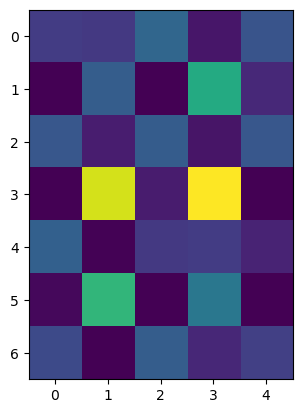

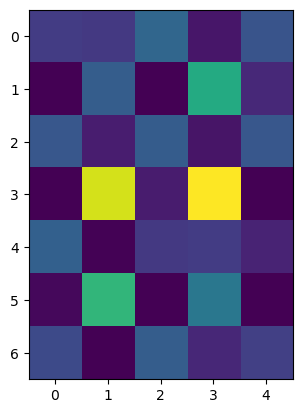

In [12]:
import matplotlib.pyplot as plt

channel_idx = 0
surf_idx = 2
energy_idx = 1
sample_idx = 4
plt.imshow(out[sample_idx, surf_idx, channel_idx, :, :, energy_idx].detach().numpy(), cmap='viridis')
plt.show()

plt.imshow(rotate_180_spatial(out_rotated)[sample_idx, surf_idx, channel_idx, :, :, energy_idx].detach().numpy())
plt.show()

In [13]:
mse = nn.MSELoss()

def compute_loss(pred, Y_flux, Y_pow, Y_keff, Y_wts):
    return (
        mse(pred['flux'], Y_flux) +
        mse(pred['pow'], Y_pow) +
        mse(pred['keff'], Y_keff) +
        mse(pred['wts'], Y_wts)
    )

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch

seed = 42
torch.manual_seed(seed)

# === Flatten tensors where necessary ===
X_flux_flat = X_flux.view(X_flux.size(0), -1).numpy()
X_wts_np    = X_wts.numpy()
Y_flux_flat = Y_flux.view(Y_flux.size(0), -1).numpy()
Y_pow_flat  = Y_pow.view(Y_pow.size(0), -1).numpy()  # <-- fix applied here
Y_keff_np   = Y_keff.view(-1, 1).numpy()
Y_wts_np    = Y_wts.numpy()

# === Create train/test splits in NumPy ===
(
    X_flux_train_np, X_flux_test_np,
    X_wts_train_np, X_wts_test_np,
    Y_flux_train_np, Y_flux_test_np,
    Y_pow_train_np, Y_pow_test_np,
    Y_keff_train_np, Y_keff_test_np,
    Y_wts_train_np, Y_wts_test_np
) = train_test_split(
    X_flux_flat, X_wts_np,
    Y_flux_flat, Y_pow_flat, Y_keff_np, Y_wts_np,
    test_size=0.2, random_state=42
)

# === Fit scalers only on training data ===
scalers = {
    'X_flux': StandardScaler().fit(X_flux_train_np),
    'X_wts': StandardScaler().fit(X_wts_train_np),
    'Y_flux': StandardScaler().fit(Y_flux_train_np),
    'Y_pow': StandardScaler().fit(Y_pow_train_np),
    'Y_keff': StandardScaler().fit(Y_keff_train_np),
    'Y_wts': StandardScaler().fit(Y_wts_train_np),
}

# === Transform both train and test sets ===
X_flux_train = torch.tensor(scalers['X_flux'].transform(X_flux_train_np), dtype=torch.float32).view(-1, *X_flux.shape[1:])
X_flux_test  = torch.tensor(scalers['X_flux'].transform(X_flux_test_np),  dtype=torch.float32).view(-1, *X_flux.shape[1:])

X_wts_train = torch.tensor(scalers['X_wts'].transform(X_wts_train_np), dtype=torch.float32)
X_wts_test  = torch.tensor(scalers['X_wts'].transform(X_wts_test_np),  dtype=torch.float32)

Y_flux_train = torch.tensor(scalers['Y_flux'].transform(Y_flux_train_np), dtype=torch.float32).view(-1, *Y_flux.shape[1:])
Y_flux_test  = torch.tensor(scalers['Y_flux'].transform(Y_flux_test_np),  dtype=torch.float32).view(-1, *Y_flux.shape[1:])

Y_pow_train = torch.tensor(scalers['Y_pow'].transform(Y_pow_train_np), dtype=torch.float32)
Y_pow_test  = torch.tensor(scalers['Y_pow'].transform(Y_pow_test_np),  dtype=torch.float32)

Y_keff_train = torch.tensor(scalers['Y_keff'].transform(Y_keff_train_np), dtype=torch.float32).squeeze(1)
Y_keff_test  = torch.tensor(scalers['Y_keff'].transform(Y_keff_test_np),  dtype=torch.float32).squeeze(1)

Y_wts_train = torch.tensor(scalers['Y_wts'].transform(Y_wts_train_np), dtype=torch.float32)
Y_wts_test  = torch.tensor(scalers['Y_wts'].transform(Y_wts_test_np),  dtype=torch.float32)

In [15]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 1. Wrap pre-normalized train and test tensors ===
train_set = TensorDataset(X_flux_train, X_wts_train, Y_flux_train, Y_pow_train, Y_keff_train, Y_wts_train)
test_set  = TensorDataset(X_flux_test,  X_wts_test,  Y_flux_test,  Y_pow_test,  Y_keff_test,  Y_wts_test)

# === 2. Create DataLoaders ===
batch_size = 1000

train_loader = DataLoader(train_set, batch_size=batch_size)  # full-batch for now
test_loader = DataLoader(test_set, batch_size=len(test_set))

# === 3. Get one full batch from train set to define input_dim ===
X_flux_train, X_wts_train, Y_flux_train, Y_pow_train, Y_keff_train, Y_wts_train = next(iter(train_loader))

# === 4. Instantiate model with shape info ===
X_input_dim = X_flux_train.view(X_flux_train.size(0), -1).size(1) + X_wts_train.size(1)
hidden_encoder = 64 # Number of channels in first layer of convolution
hidden_decoder = 48
hidden = 48
hidden_dim = 128
embedding = 48
model = EquivariantModel(
    hidden_encoder=hidden_encoder, 
    encoder_out=embedding, 
    option='downsample',
    num_encoder_layers=2, 
    gnn_hidden=embedding, 
    gnn_out=embedding, 
    num_gnn_layers=3,
    hidden_decoder_channels=hidden_decoder, 
    hidden_decoder_coef=hidden_dim, 
    hidden_decoder_keff=hidden_dim, 
    hidden_decoder_pow=hidden_dim, 
    num_decoder_layers=4,
    kernel_dim=3
).to(device)

# Weight initialization
def init_weights(m):
    if isinstance(m, nn.Conv3d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.ConvTranspose3d):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
            
model.apply(init_weights)

num_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {num_params}")

Total number of parameters: 2167680


In [ ]:
from tqdm import tqdm

epochs = 200
steps_per_epoch = len(train_loader)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-2)
# schedule = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=1000,
# )
# schedule = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=1e-2,
#     epochs=epochs,
#     steps_per_epoch=steps_per_epoch,
#     pct_start=0.1,           # 10% warm-up
#     anneal_strategy='cos',   # cosine decay
#     div_factor=25.0,         # initial LR = max_lr / div_factor
#     final_div_factor=1e4     # final LR = initial / final_div_factor
# )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',              # or 'max'
    factor=0.5,              # new_lr = lr * factor
    patience=5,             # wait 10 epochs before reducing
    threshold=1e-4,          # minimum change to count as improvement
    min_lr=1e-6,             # don’t go lower than this
)
progress_bar = tqdm(range(epochs), desc="Training", position=0)

train_losses = []
test_losses = []
for epoch in progress_bar:
    model.train()

    for X_flux_batch, X_wts_batch, Y_flux_batch, Y_pow_batch, Y_keff_batch, Y_wts_batch in train_loader:
        X_flux_batch = X_flux_batch.to(device)
        X_wts_batch  = X_wts_batch.to(device)
        Y_flux_batch = Y_flux_batch.to(device)
        Y_pow_batch  = Y_pow_batch.to(device)
        Y_keff_batch = Y_keff_batch.to(device)
        Y_wts_batch  = Y_wts_batch.to(device)
        
        pred = model(X_flux_batch, X_wts_batch)
        loss = compute_loss(pred, Y_flux_batch, Y_pow_batch, Y_keff_batch, Y_wts_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        for X_flux_test, X_wts_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test in test_loader:
            X_flux_test = X_flux_test.to(device)
            X_wts_test  = X_wts_test.to(device)
            Y_flux_test = Y_flux_test.to(device)
            Y_pow_test  = Y_pow_test.to(device)
            Y_keff_test = Y_keff_test.to(device)
            Y_wts_test  = Y_wts_test.to(device)

            pred_test = model(X_flux_test, X_wts_test)
            test_loss = compute_loss(pred_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    progress_bar.set_description(f"Epoch {epoch}/{epochs}: Train Loss = {loss.item():.4f} | Test Loss = {test_loss.item():.4f}")

# === 8. Evaluate on test set ===
model.eval()
with torch.no_grad():
    for X_flux_test, X_wts_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test in test_loader:
        X_flux_test = X_flux_test.to(device)
        X_wts_test  = X_wts_test.to(device)
        Y_flux_test = Y_flux_test.to(device)
        Y_pow_test  = Y_pow_test.to(device)
        Y_keff_test = Y_keff_test.to(device)
        Y_wts_test  = Y_wts_test.to(device)

        pred_test = model(X_flux_test, X_wts_test)
        test_loss = compute_loss(pred_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test)

print(f"Final Test Loss: {test_loss.item():.4f}")

Epoch 37/200: Train Loss = 4.2839 | Test Loss = 14.1833:  19%|█▉        | 38/200 [08:16<35:28, 13.14s/it] 

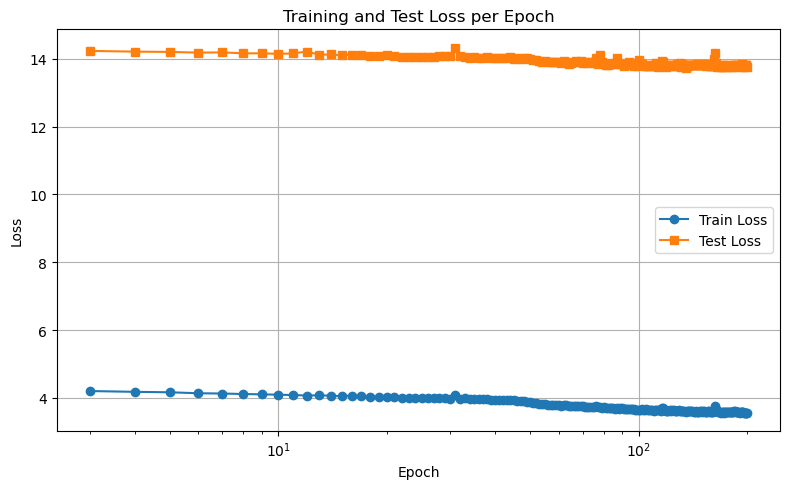

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Skip the very large initial training error
start_idx = 2
plt.figure(figsize=(8, 5))
plt.plot(epochs[start_idx:], train_losses[start_idx:], label='Train Loss', marker='o')
plt.plot(epochs[start_idx:], test_losses[start_idx:], label='Test Loss', marker='s')
# plt.yscale('log')
plt.xscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss per Epoch')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
plt.show()

In [18]:
class ScaledModelWrapper:
    def __init__(self, model, scalers, device="cpu"):
        self.model = model.to(device)
        self.scalers = scalers
        self.device = device

    def _normalize_input(self, X_flux, X_wts):
        X_flux_flat = X_flux.view(X_flux.size(0), -1).numpy()
        X_wts_np = X_wts.numpy()

        X_flux_scaled = self.scalers['X_flux'].transform(X_flux_flat)
        X_wts_scaled = self.scalers['X_wts'].transform(X_wts_np)

        X_flux_tensor = torch.tensor(X_flux_scaled, dtype=torch.float32).view_as(X_flux).to(self.device)
        X_wts_tensor = torch.tensor(X_wts_scaled, dtype=torch.float32).to(self.device)

        return X_flux_tensor, X_wts_tensor

    def _denormalize_output(self, out):
        out_denorm = {}

        Y_flux_flat = out['flux'].view(out['flux'].size(0), -1).cpu().numpy()
        out_denorm['flux'] = torch.tensor(
            self.scalers['Y_flux'].inverse_transform(Y_flux_flat),
            dtype=torch.float32
        ).view_as(out['flux'])

        Y_pow_flat = out['pow'].view(out['pow'].size(0), -1).cpu().numpy()
        out_denorm['pow'] = torch.tensor(
            self.scalers['Y_pow'].inverse_transform(Y_pow_flat),
            dtype=torch.float32
        )

        Y_keff = out['keff'].view(-1, 1).cpu().numpy()
        out_denorm['keff'] = torch.tensor(
            self.scalers['Y_keff'].inverse_transform(Y_keff),
            dtype=torch.float32
        ).squeeze(1)

        Y_wts = out['wts'].cpu().numpy()
        out_denorm['wts'] = torch.tensor(
            self.scalers['Y_wts'].inverse_transform(Y_wts),
            dtype=torch.float32
        )

        return out_denorm

    def predict(self, X_flux, X_wts):
        self.model.eval()
        with torch.no_grad():
            X_flux_norm, X_wts_norm = self._normalize_input(X_flux, X_wts)
            out = self.model(X_flux_norm, X_wts_norm)
            out_denorm = self._denormalize_output(out)
        return out_denorm


In [19]:
wrapped_model = ScaledModelWrapper(model, scalers)

test_index = -20
X_flux_sample = X_flux[test_index:test_index+1].cpu()
X_wts_sample  = X_wts[test_index:test_index+1].cpu()

out = wrapped_model.predict(X_flux_sample, X_wts_sample)

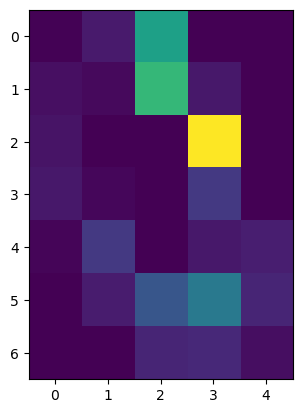

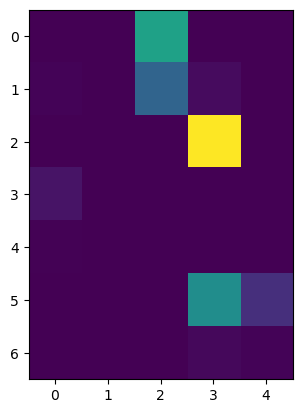

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(out['flux'][0, 0, 0, :, :, 0])
plt.show()
plt.imshow(Y_flux[test_index, 0, 0, :, :, 0].cpu())
plt.show()

In [21]:
out['keff'], Y_keff[test_index]

(tensor([0.7273]), tensor(0.7324))

In [22]:
out['wts'], Y_wts[test_index]

(tensor([[0.3127, 0.3120, 0.2095, 0.2101]]),
 tensor([0.2955, 0.2928, 0.2002, 0.2115]))

## Compare the Full Flux Surface Expansion

In [23]:
from pincell_moment_utils import postprocessing as pp
from pincell_moment_utils.datagen import DefaultPincellParameters

energy_filters = DefaultPincellParameters().get_energy_filters()

pred_coefficients = np.moveaxis(out['flux'][0].cpu().numpy(), 1, -1)
true_coefficients = np.moveaxis(Y_flux[test_index].cpu().numpy(), 1, -1)

pred_expansion = pp.surface_expansion(np.clip(pred_coefficients, a_min=0, a_max=None), energy_filters, expansion_type='bernstein_bernstein')
expansion = pp.surface_expansion(true_coefficients, energy_filters, expansion_type='bernstein_bernstein')

In [24]:
np.clip(pred_coefficients, a_min=0, a_max=None)

array([[[[[3.49834859e-02],
          [2.99717784e-02],
          [9.12096817e-03],
          ...,
          [4.73446448e-07],
          [2.85338619e-09],
          [7.01357444e-11]],

         [[3.22367549e-01],
          [1.78883642e-01],
          [4.45578732e-02],
          ...,
          [1.70895862e-06],
          [1.59447264e-08],
          [4.64890615e-09]],

         [[2.58561635e+00],
          [2.75095534e+00],
          [1.24507439e+00],
          ...,
          [3.95101451e-05],
          [2.23318040e-07],
          [1.11138867e-08]],

         [[0.00000000e+00],
          [2.70574470e-04],
          [5.22962771e-03],
          ...,
          [2.68740195e-07],
          [8.56044957e-11],
          [3.09737885e-13]],

         [[0.00000000e+00],
          [0.00000000e+00],
          [4.67304702e-08],
          ...,
          [2.05594852e-09],
          [8.85200523e-14],
          [4.85171663e-15]]],


        [[[1.94660738e-01],
          [1.08361587e-01],
          [5.3575

In [25]:
true_coefficients[0, :, :, 0]

array([[[0.        ],
        [0.        ],
        [3.7583897 ],
        [0.        ],
        [0.        ]],

       [[0.06658287],
        [0.        ],
        [2.1185129 ],
        [0.19180672],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [6.58094   ],
        [0.        ]],

       [[0.34700775],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.04886367],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [3.2240427 ],
        [0.885784  ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.12899669],
        [0.05264866]]], dtype=float32)

In [30]:
pred_expansion.integrate_flux(0), expansion.integrate_flux(0)

(1.2461922878622096, 0.999999937323981)

/home/mlouis9/shared/Educational Stuffs/Classes/Spring 2025/Stat ML/Project/data_generation/src/pincell_moment_utils/plotting.py:48: RuntimeWarning: invalid value encountered in divide
  expansion_vals = np.abs(expansion_vals) / np.abs(compare_expansion.evaluate_on_grid(surface, (space_vals, angle_vals, energy_vals)))


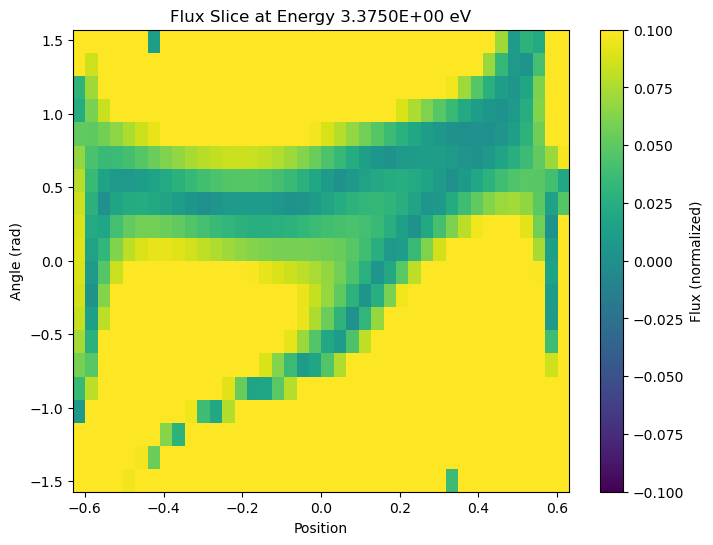

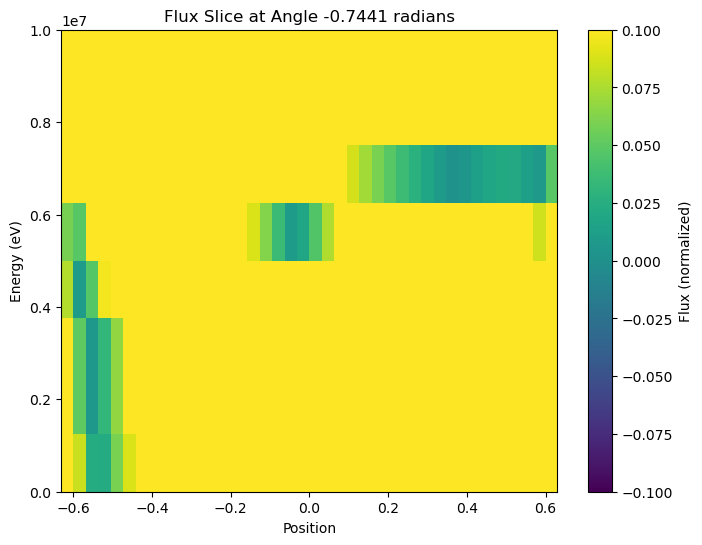

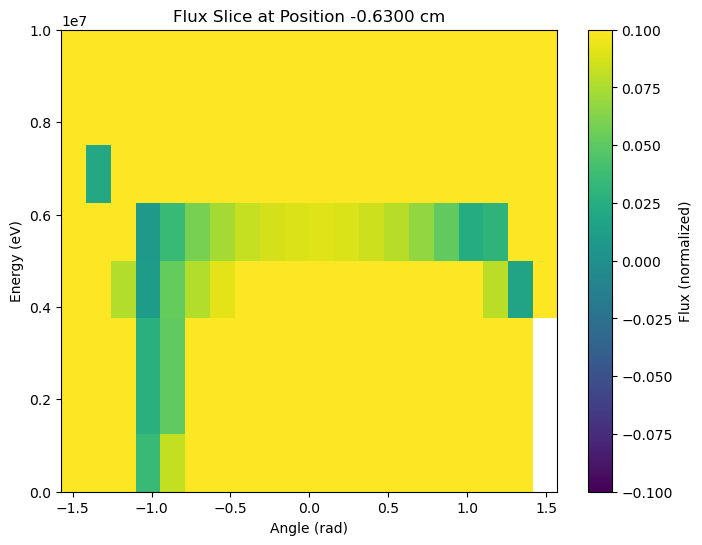

In [ ]:
from pincell_moment_utils.plotting import plot_expansion

plot_expansion(expansion, 0, 5, 4, 0, 40, 20, incident=False, compare_expansion=pred_expansion)

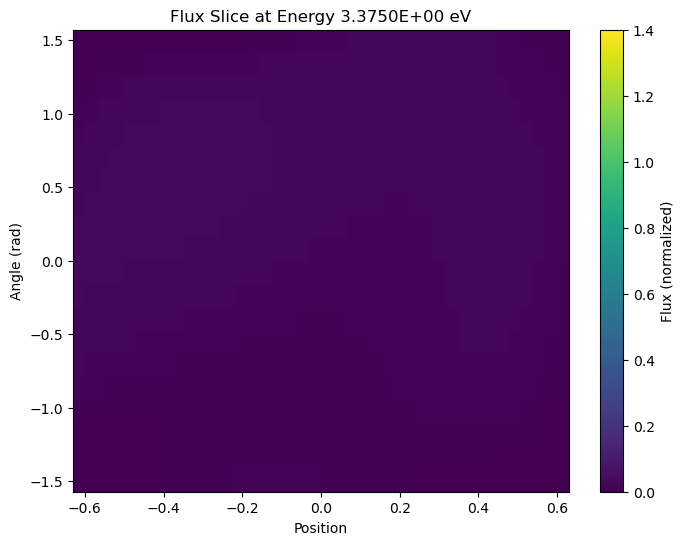

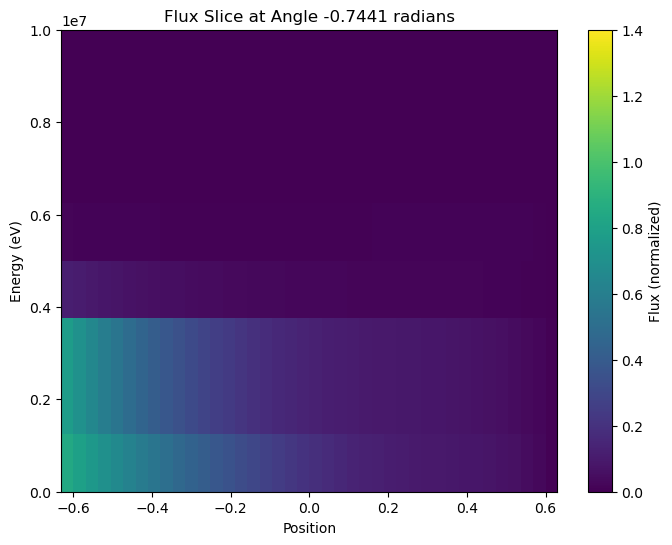

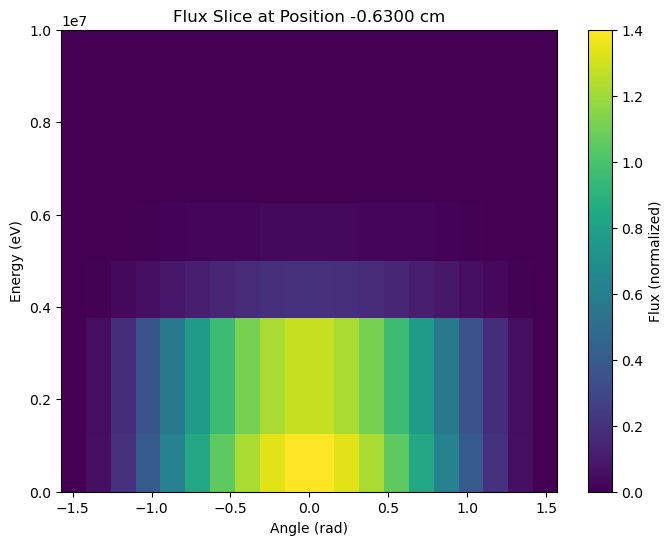

In [ ]:
plot_expansion(expansion, 0, 5, 4, 0, 40, 20, incident=False)

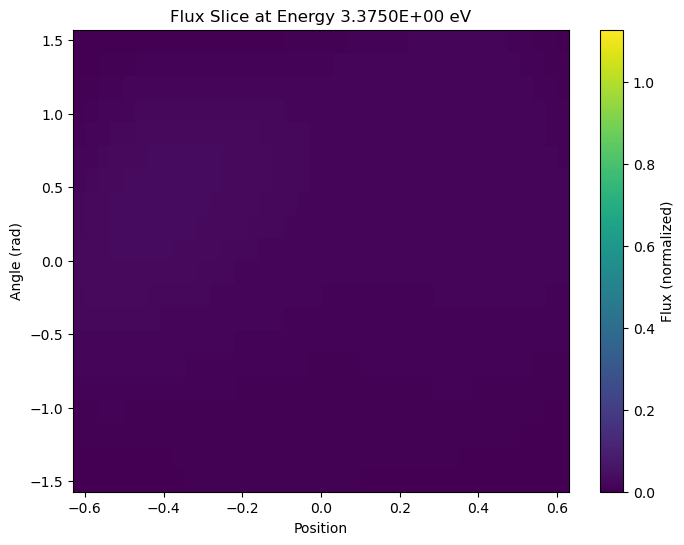

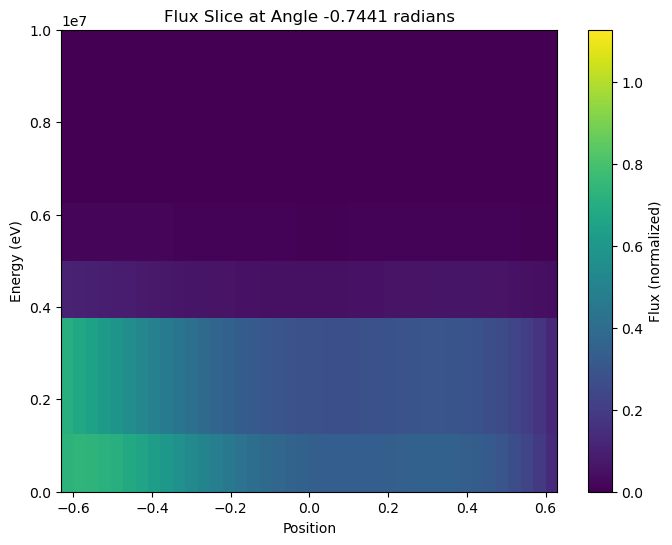

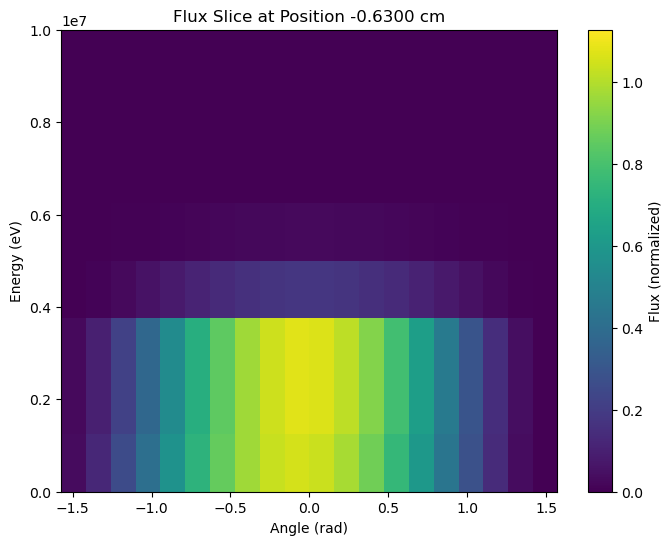

In [29]:
plot_expansion(pred_expansion, 0, 5, 4, 0, 40, 20, incident=False)